In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cell_data = pd.read_csv("cell_samples.csv")
print(cell_data.head())

        ID  Clump  UnifSize  UnifShape  MargAdh  SingEpiSize BareNuc  \
0  1000025      5         1          1        1            2       1   
1  1002945      5         4          4        5            7      10   
2  1015425      3         1          1        1            2       2   
3  1016277      6         8          8        1            3       4   
4  1017023      4         1          1        3            2       1   

   BlandChrom  NormNucl  Mit  Class  
0           3         1    1      2  
1           3         2    1      2  
2           3         1    1      2  
3           3         7    1      2  
4           3         1    1      2  


In [3]:
print(cell_data.shape)
print(cell_data.dtypes)

(699, 11)
ID             int64
Clump          int64
UnifSize       int64
UnifShape      int64
MargAdh        int64
SingEpiSize    int64
BareNuc          str
BlandChrom     int64
NormNucl       int64
Mit            int64
Class          int64
dtype: object


In [4]:
print(cell_data["Class"].value_counts())

Class
2    458
4    241
Name: count, dtype: int64


In [5]:
print(cell_data["BareNuc"].value_counts())

BareNuc
1     402
10    132
2      30
5      30
3      28
8      21
4      19
?      16
9       9
7       8
6       4
Name: count, dtype: int64


<Axes: >

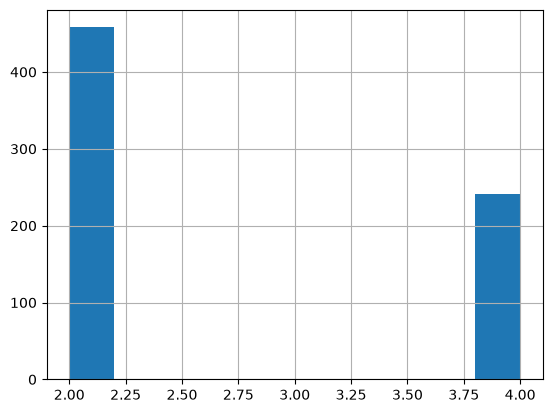

In [6]:
cell_data["Class"].hist()

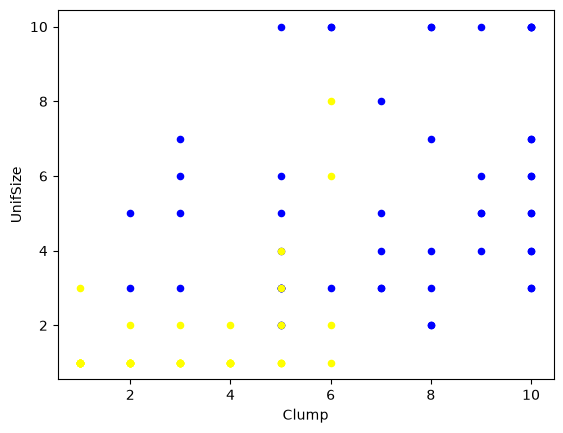

In [7]:
ax = cell_data[cell_data["Class"] == 4][0:50].plot(kind="scatter", x="Clump", y="UnifSize", color="Blue")
cell_data[cell_data["Class"] == 2][0:50].plot(kind="scatter", x="Clump", y="UnifSize", color="Yellow", ax=ax)
plt.show()


In [8]:
cell_data = cell_data[pd.to_numeric(cell_data["BareNuc"], errors="coerce").notnull()]
cell_data["BareNuc"] = cell_data["BareNuc"].astype("int")
cell_data.dtypes

ID             int64
Clump          int64
UnifSize       int64
UnifShape      int64
MargAdh        int64
SingEpiSize    int64
BareNuc        int64
BlandChrom     int64
NormNucl       int64
Mit            int64
Class          int64
dtype: object

In [10]:
feature_df = cell_data[["Clump", "UnifSize", "UnifShape", "MargAdh", "SingEpiSize", "BareNuc", "BlandChrom", "NormNucl", "Mit"]]
X = np.asanyarray(feature_df)
X[:5]

array([[ 5,  1,  1,  1,  2,  1,  3,  1,  1],
       [ 5,  4,  4,  5,  7, 10,  3,  2,  1],
       [ 3,  1,  1,  1,  2,  2,  3,  1,  1],
       [ 6,  8,  8,  1,  3,  4,  3,  7,  1],
       [ 4,  1,  1,  3,  2,  1,  3,  1,  1]])

In [12]:
y = np.asanyarray(cell_data["Class"].astype(int))
y[:5]

array([2, 2, 2, 2, 2])

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

print(X_train[:5])
print("-------------------------------------")
print(X_test[:5])
print("-------------------------------------")
print(y_train[:5])
print("-------------------------------------")
print(y_test[:5])

[[ 9 10 10 10 10  5 10 10 10]
 [ 2  1  1  1  2  1  3  1  1]
 [ 4  1  1  1  2  1  1  1  1]
 [ 5  5  5  2  5 10  4  3  1]
 [ 5  4  6  6  4 10  4  3  1]]
-------------------------------------
[[ 3  1  1  1  2  1  2  1  2]
 [ 5 10 10  8  5  5  7 10  1]
 [ 5  1  1  1  2  1  2  1  1]
 [10 10 10  8  2 10  4  1  1]
 [ 2  1  1  1  1  1  3  1  1]]
-------------------------------------
[4 2 2 4 4]
-------------------------------------
[2 4 2 4 2]


In [17]:
from sklearn import svm

svm_model = svm.SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [18]:
yhat = svm_model.predict(X_test)
yhat[:5]

array([2, 4, 2, 4, 2])

In [22]:
from sklearn.metrics import jaccard_score, f1_score, classification_report, confusion_matrix

print(jaccard_score(y_test, yhat, pos_label=2))
print("-------------------------------------")
print(f1_score(y_test, yhat, average='weighted'))
print("-------------------------------------")
print(classification_report(y_test, yhat))

0.9444444444444444
-------------------------------------
0.9639038982104676
-------------------------------------
              precision    recall  f1-score   support

           2       1.00      0.94      0.97        90
           4       0.90      1.00      0.95        47

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.97      0.96      0.96       137

